# Light-map scattering-length comparison
This notebook compares total collection, summed response in each fibre view, the response of the single nearest fibre in each view, and the view-to-view imbalance. RMS in the per-view statistics means the population spread across the 970 source subvoxels; view RMS means the population RMS among X/Y/Z for one subvoxel. It also compares the mean transverse radii containing 0.5, 0.7, 0.8, and 0.9 of the light from central ten-subvoxel tracks, normalized either to collected light or to all launched photons.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from compare_lightmap_efficiencies import compare_lightmaps

In [2]:
maps = Path('lightmaps')
settings = [
    (0.25, '0.25 mm', maps / 'homo_response_10bin_5m_0p25mm_100kPhotons.root'),
    (0.40, '0.40 mm', maps / 'homo_response_10bin_5m_0p4mm_100kPhotons.root'),
    (0.55, '0.55 mm', maps / 'homo_response_10bin_5m_0p55mm_fibre-1p0mm_100kPhotons.root'),
    (0.70, '0.70 mm', maps / 'homo_response_10bin_5m_0p7mm_100kPhotons.root'),
    (0.85, '0.85 mm', maps / 'homo_response_10bin_5m_0p85mm_fibre-1p0mm_100kPhotons.root'),
    (1.00, '1.00 mm', maps / 'homo_response_10bin_5m_1p0mm_100kPhotons.root'),
    (1.50, '1.50 mm', maps / 'homo_response_10bin_5m_1p5mm_fibre-1p0mm_100kPhotons.root'),
]
output_dir = Path('lightmap_analysis/scattering_comparison')
summaries, detailed = compare_lightmaps(settings, output_dir)
summary = pd.DataFrame(summaries).sort_values('scatter_length_mm')
summary

,scatter_length_mm,label,input,positions,total_mean,total_min,total_max,total_rms,view_x_mean,view_x_min,...,absolute_r70_z_mm,absolute_r70_mean_mm,absolute_r80_x_mm,absolute_r80_y_mm,absolute_r80_z_mm,absolute_r80_mean_mm,absolute_r90_x_mm,absolute_r90_y_mm,absolute_r90_z_mm,absolute_r90_mean_mm
0,0.25,0.25 mm,lightmaps/homo_response_10bin_5m_0p25mm_100kPh...,970,0.813149,0.80642,0.81744,0.001919,0.271042,0.10460,...,7.28011,7.28011,13.152946,13.152946,13.152946,13.152946,NaN,NaN,NaN,NaN
1,0.40,0.40 mm,lightmaps/homo_response_10bin_5m_0p4mm_100kPho...,970,0.870520,0.86529,0.87503,0.001756,0.290160,0.12984,...,7.28011,7.28011,8.544004,8.544004,8.544004,8.544004,NaN,NaN,NaN,NaN
2,0.55,0.55 mm,lightmaps/homo_response_10bin_5m_0p55mm_fibre-...,970,0.900306,0.89438,0.90438,0.001636,0.300174,0.14933,...,7.28011,7.09337,8.544004,8.544004,8.544004,8.544004,23.086793,23.086793,28.000000,24.724529
3,0.70,0.70 mm,lightmaps/homo_response_10bin_5m_0p7mm_100kPho...,970,0.918565,0.91411,0.92217,0.001475,0.306159,0.16300,...,7.28011,7.28011,8.544004,8.544004,8.544004,8.544004,17.000000,17.000000,17.000000,17.000000
4,0.85,0.85 mm,lightmaps/homo_response_10bin_5m_0p85mm_fibre-...,970,0.930878,0.92513,0.93395,0.001414,0.310345,0.17614,...,7.28011,7.28011,8.544004,8.544004,8.544004,8.544004,15.264338,15.264338,15.264338,15.264338
5,1.00,1.00 mm,lightmaps/homo_response_10bin_5m_1p0mm_100kPho...,970,0.939875,0.93603,0.94280,0.001282,0.313318,0.18797,...,7.28011,7.28011,8.544004,8.544004,8.544004,8.544004,15.264338,15.264338,15.264338,15.264338
6,1.50,1.50 mm,lightmaps/homo_response_10bin_5m_1p5mm_fibre-1...,970,0.957288,0.95398,0.95963,0.001071,0.319156,0.21163,...,8.00000,8.00000,10.630146,10.630146,10.630146,10.630146,17.000000,17.000000,17.000000,17.000000


Warning in <TClass::Init>: no dictionary for class ND::TND280Event is available
Warning in <TClass::Init>: no dictionary for class ND::TDataVector is available
Warning in <TClass::Init>: no dictionary for class ND::TData is available
Warning in <TClass::Init>: no dictionary for class ND::TDatum is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Context is available
Warning in <TClass::Init>: no dictionary for class ND::TSHAHashValue is available
Warning in <TClass::Init>: no dictionary for class ND::TAlignmentId is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Event::Header is available


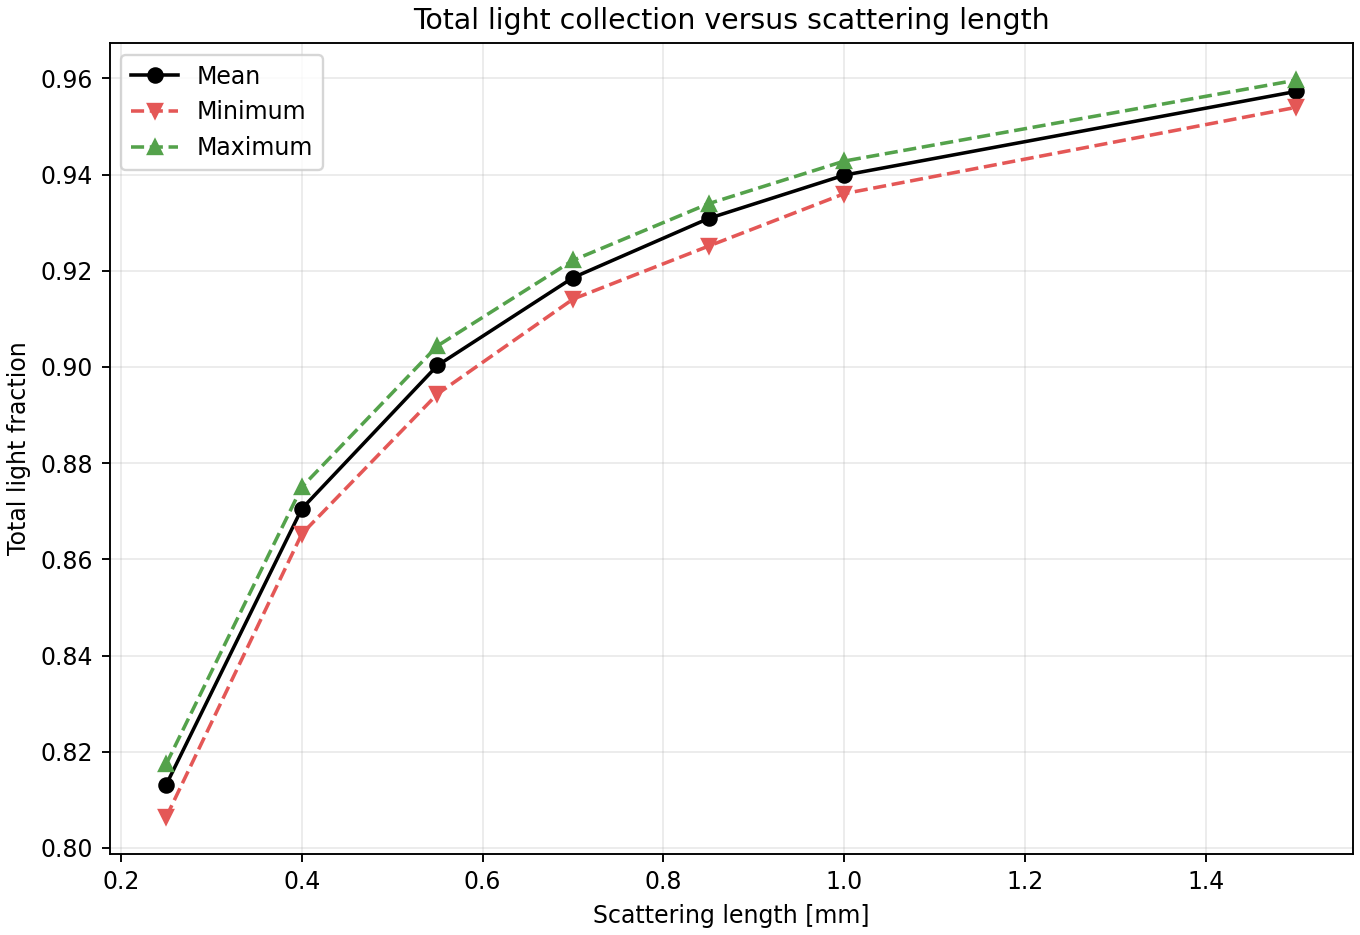

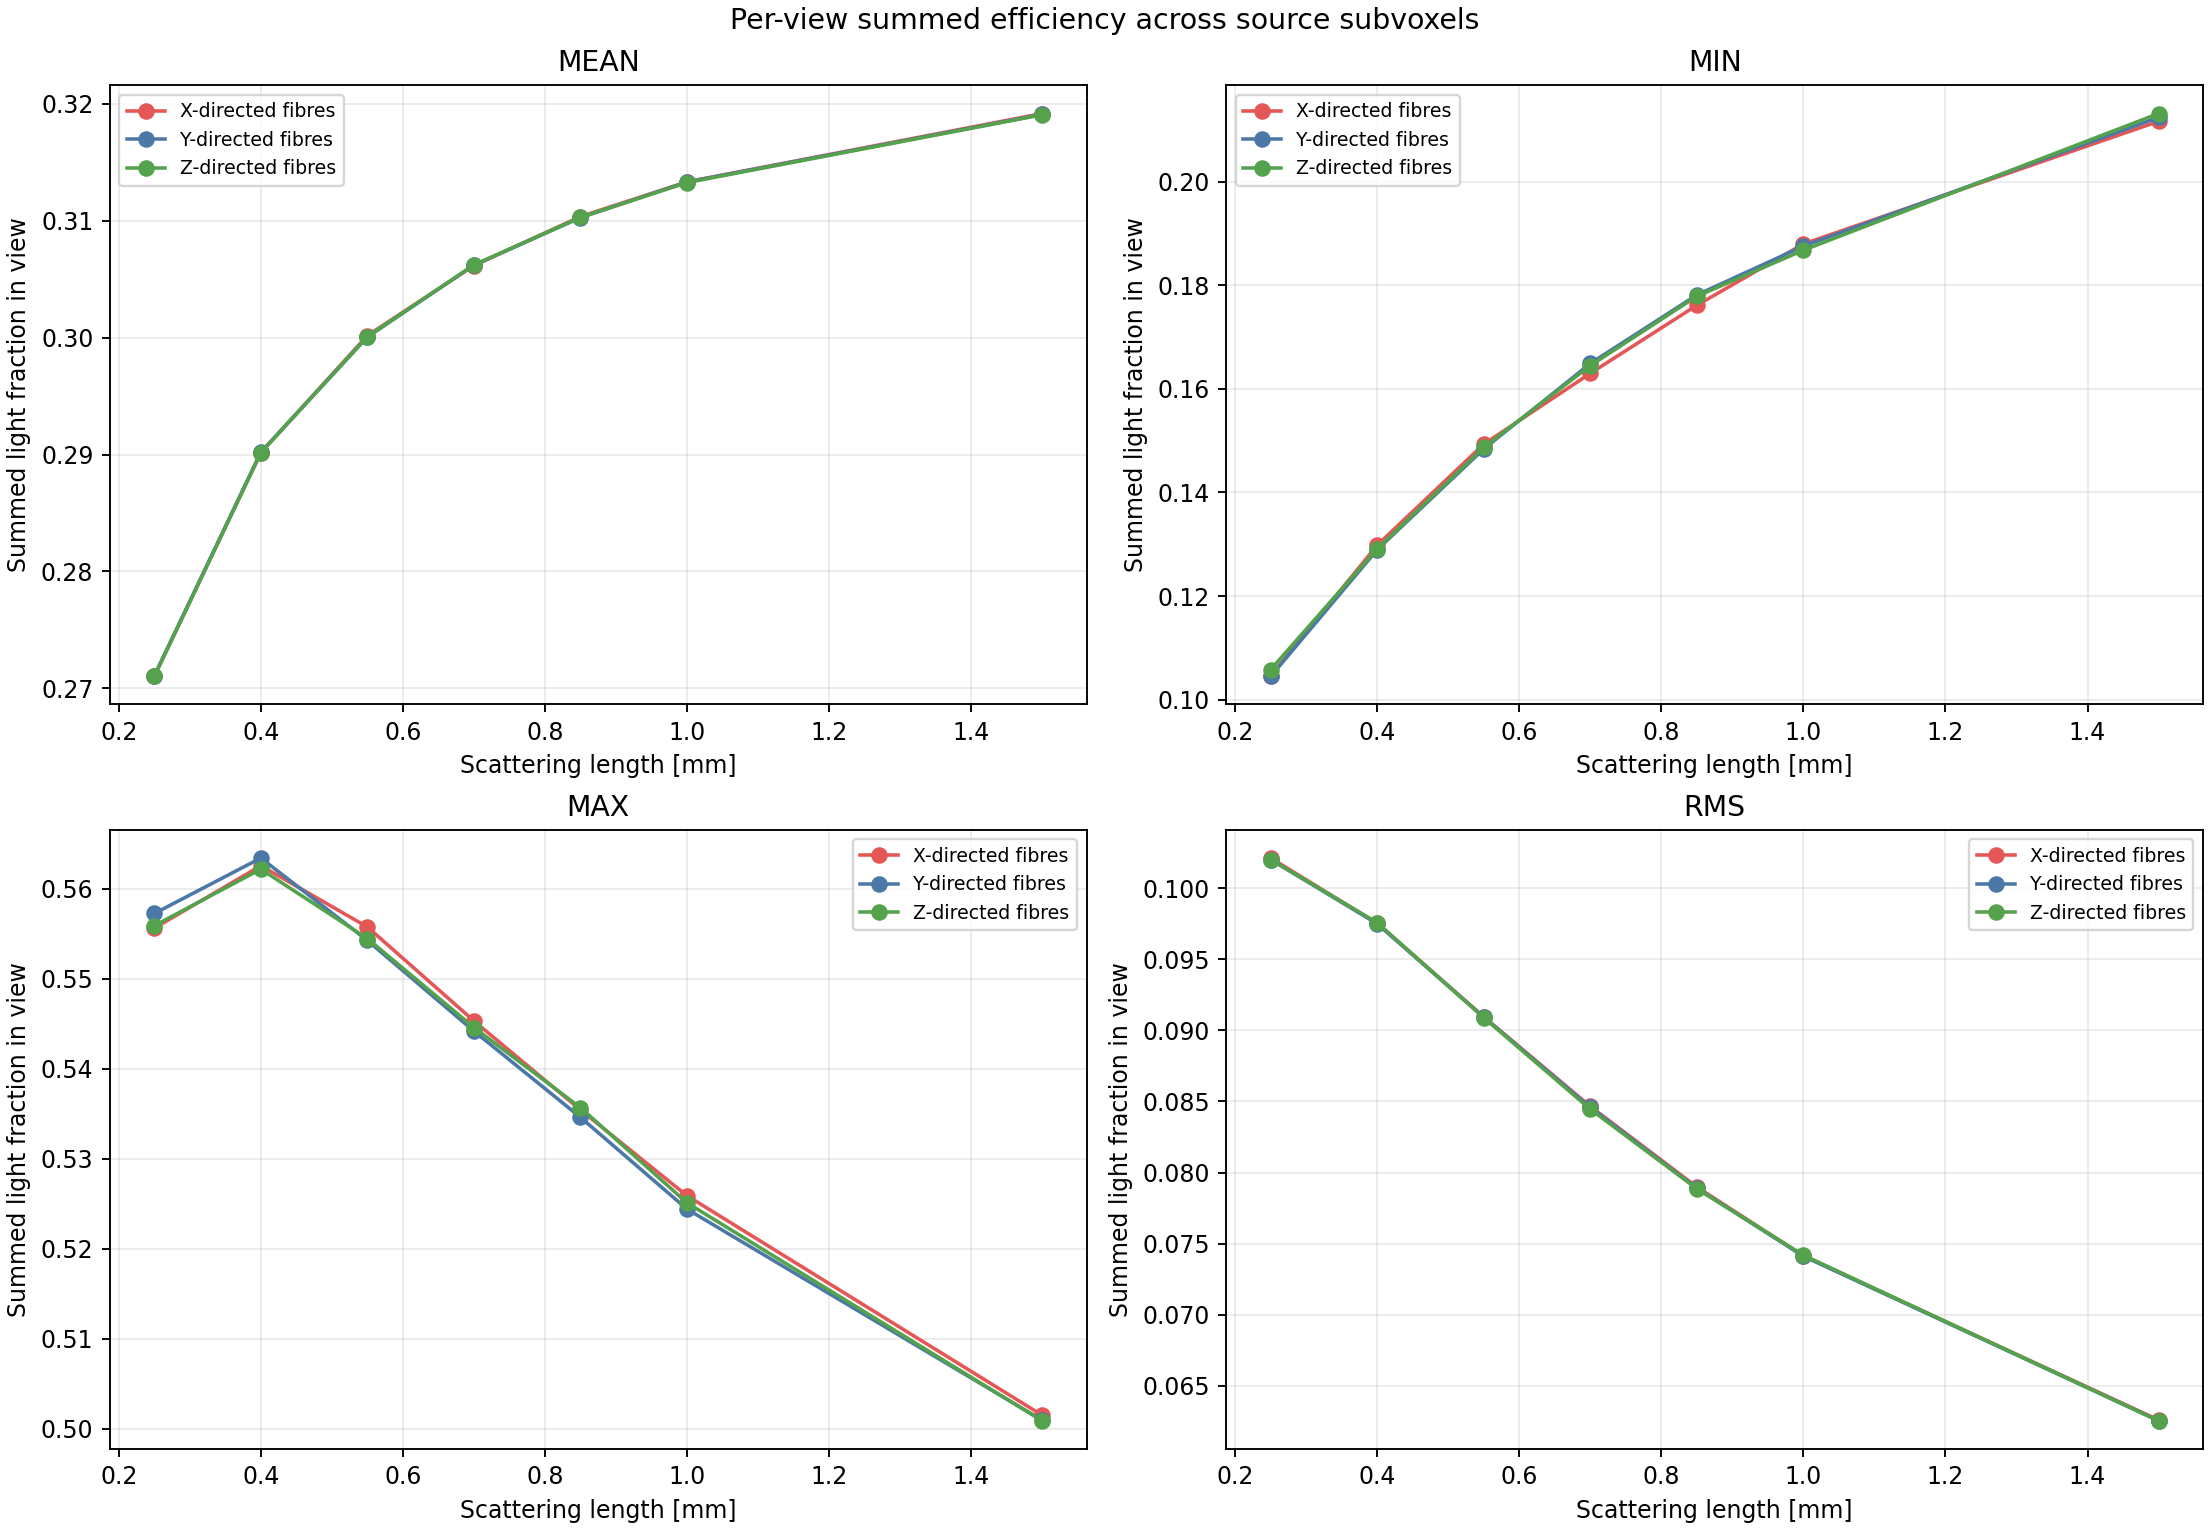

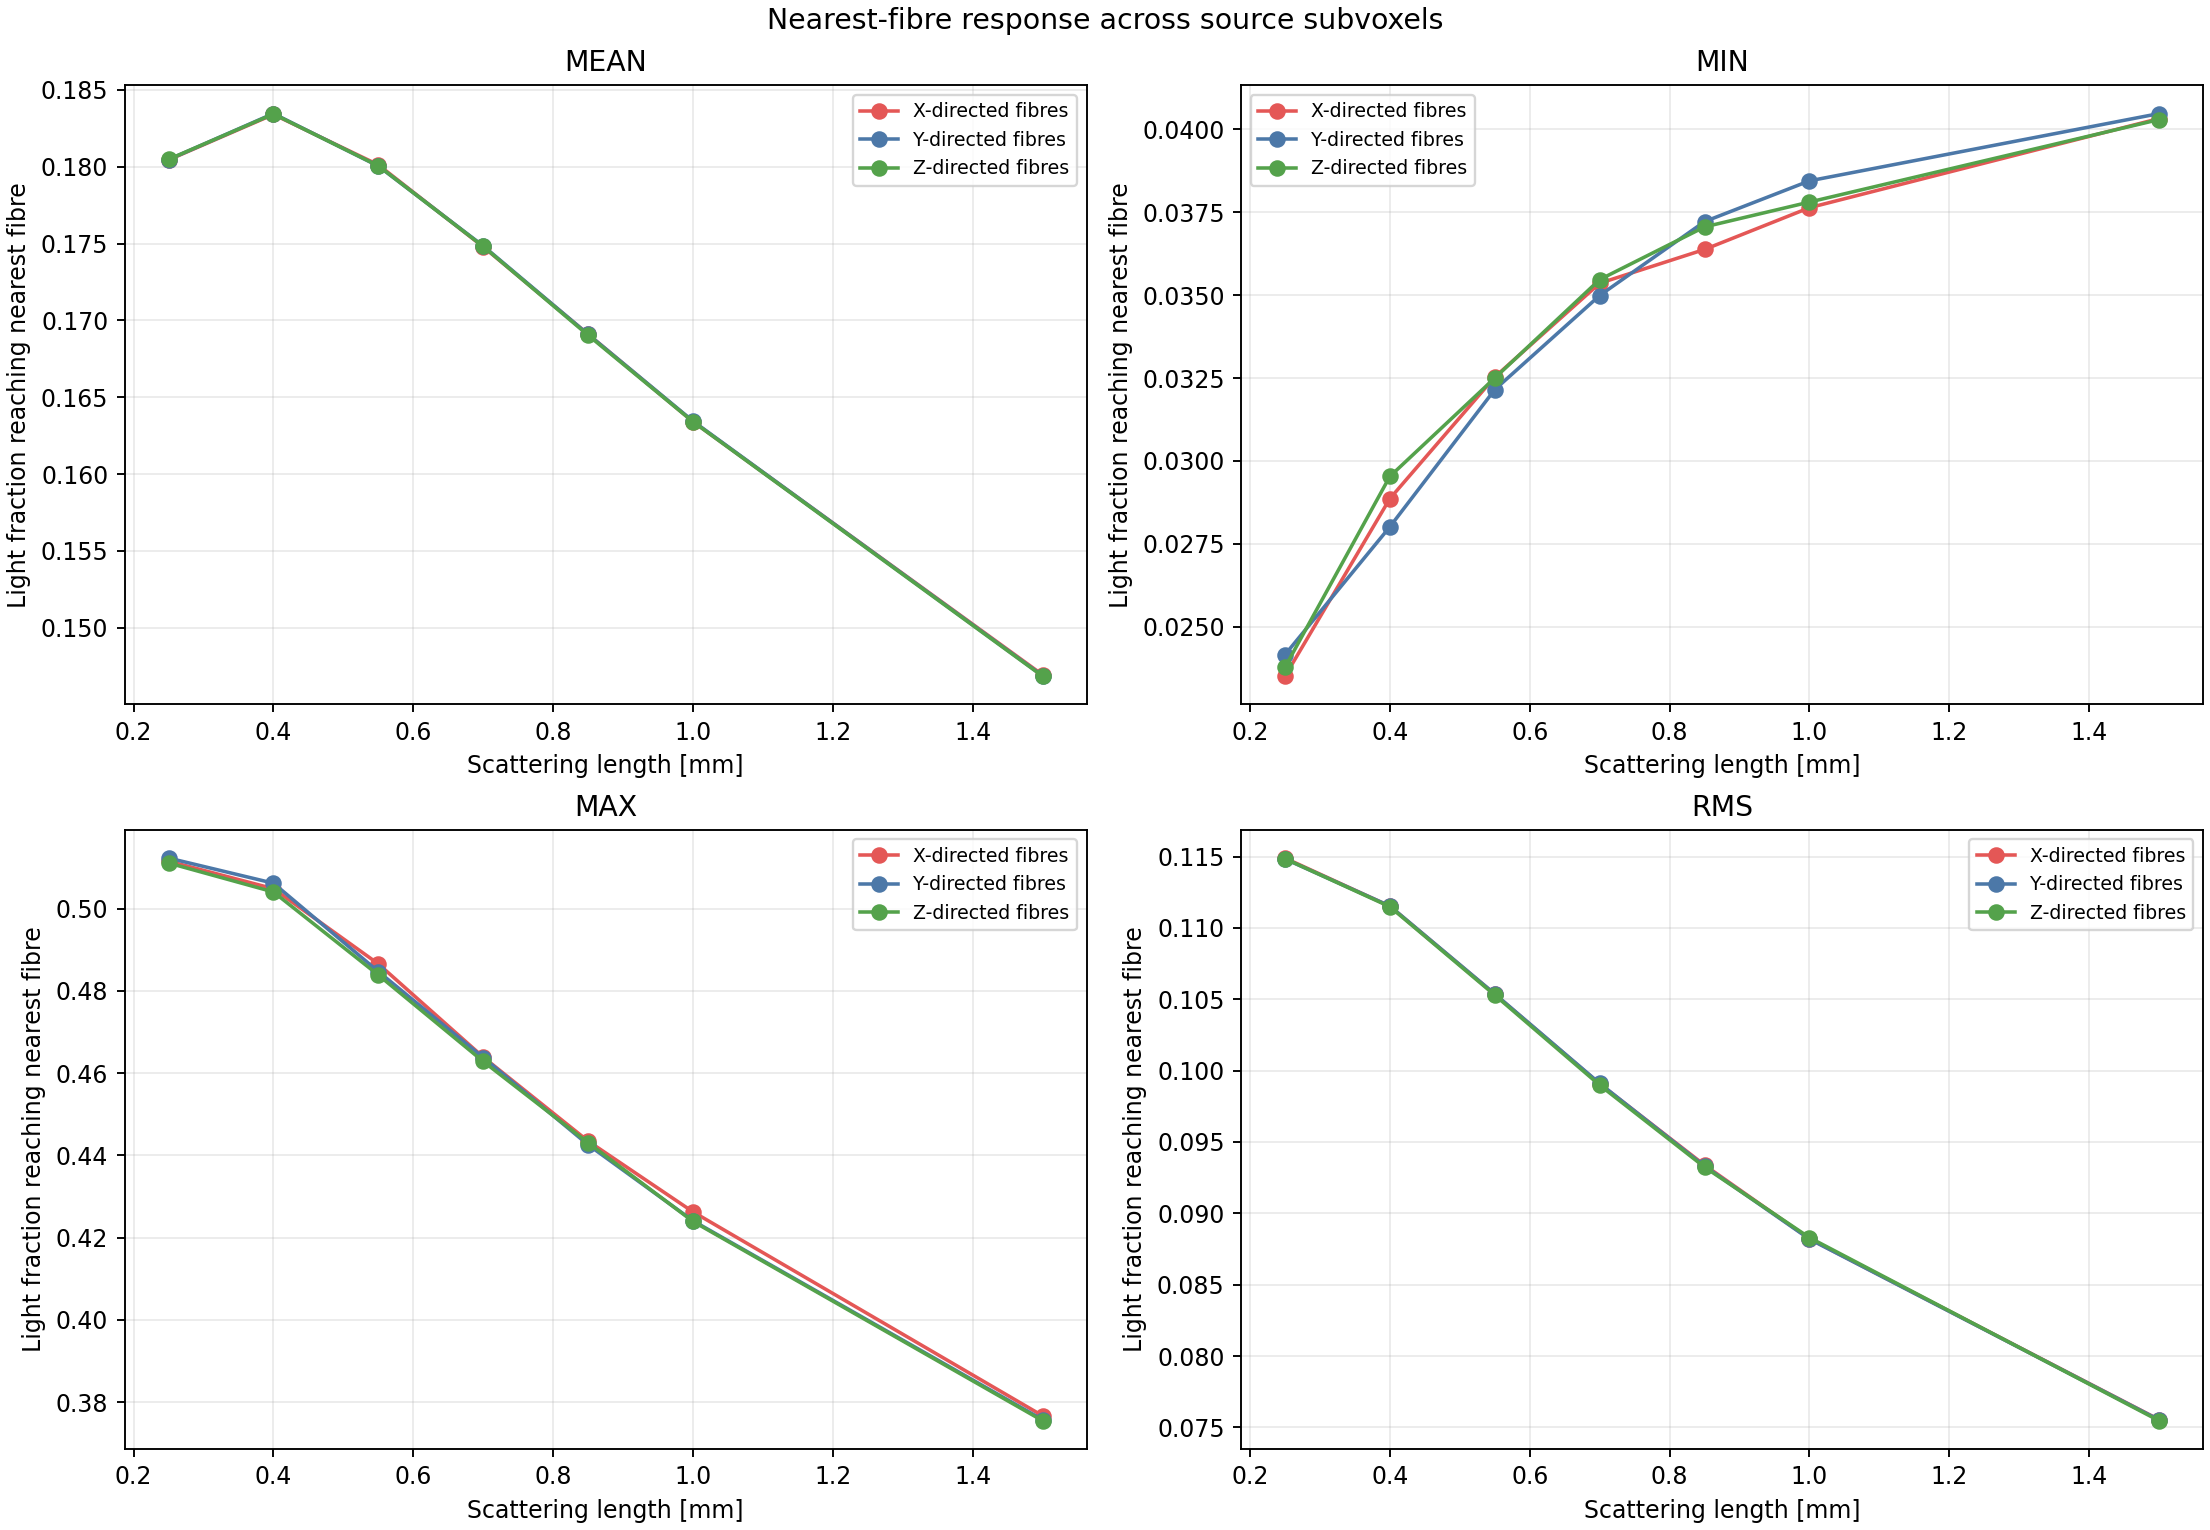

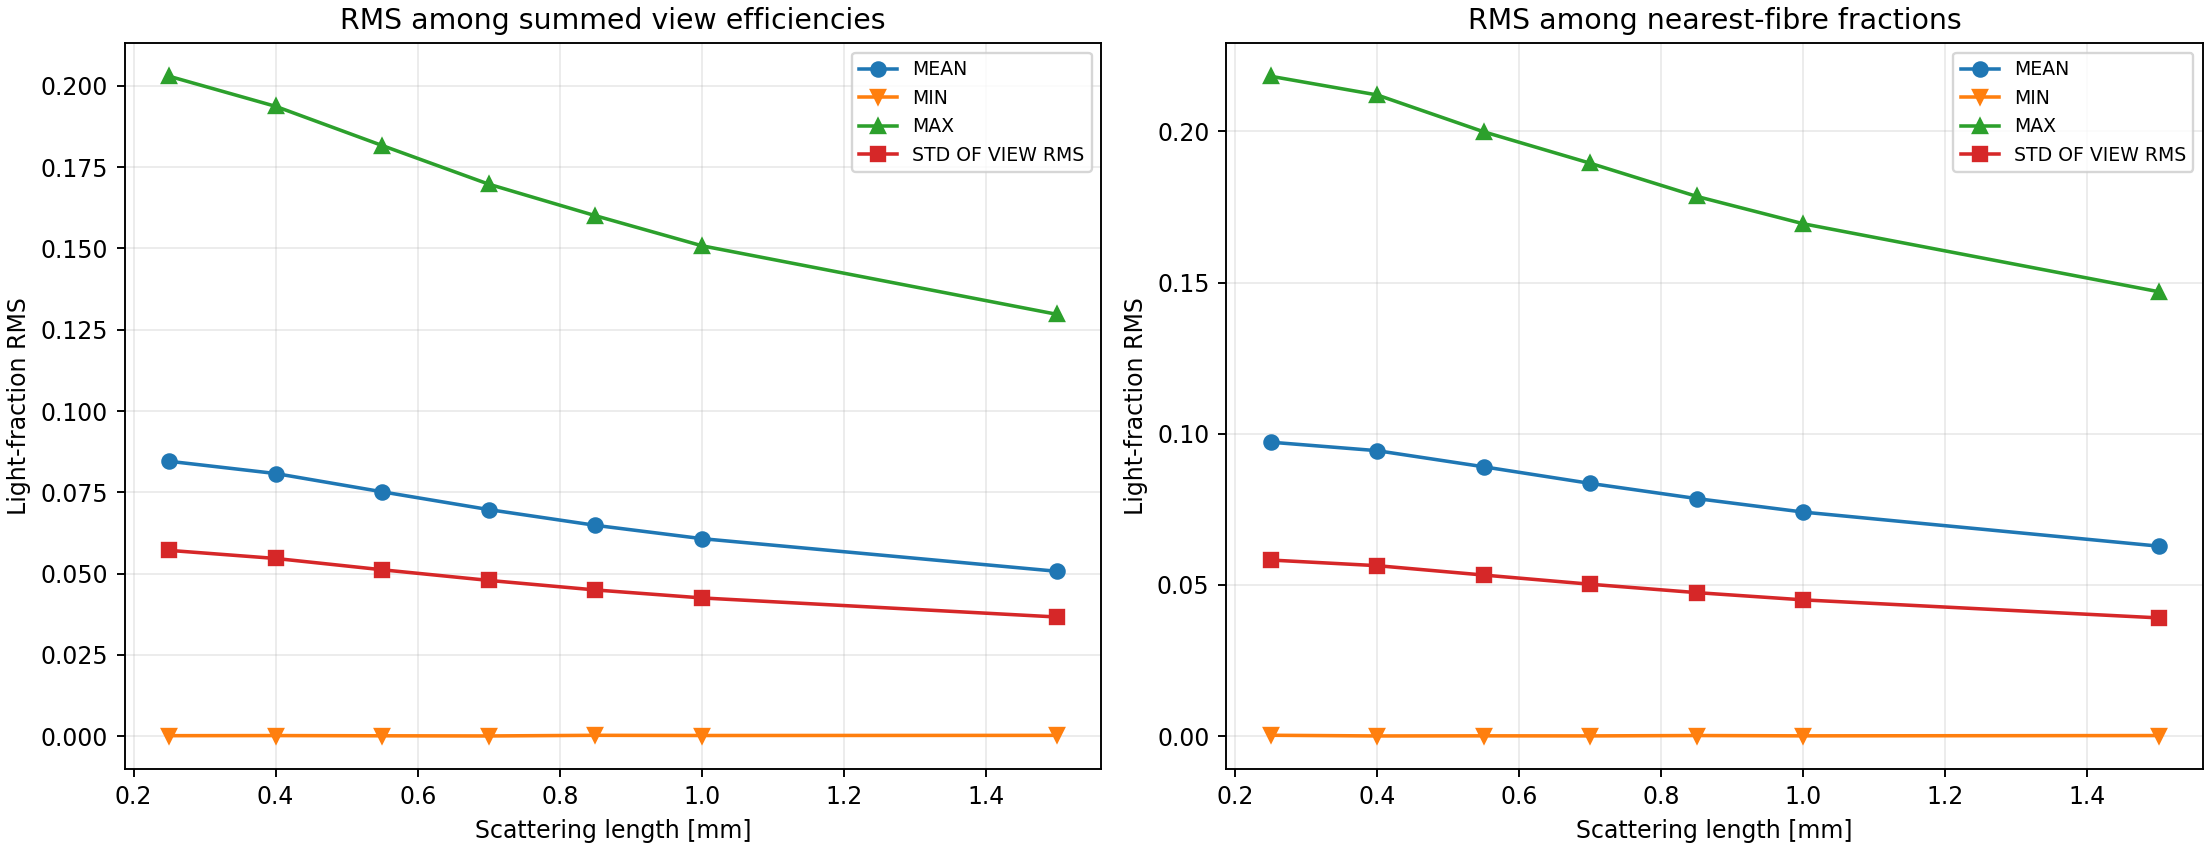

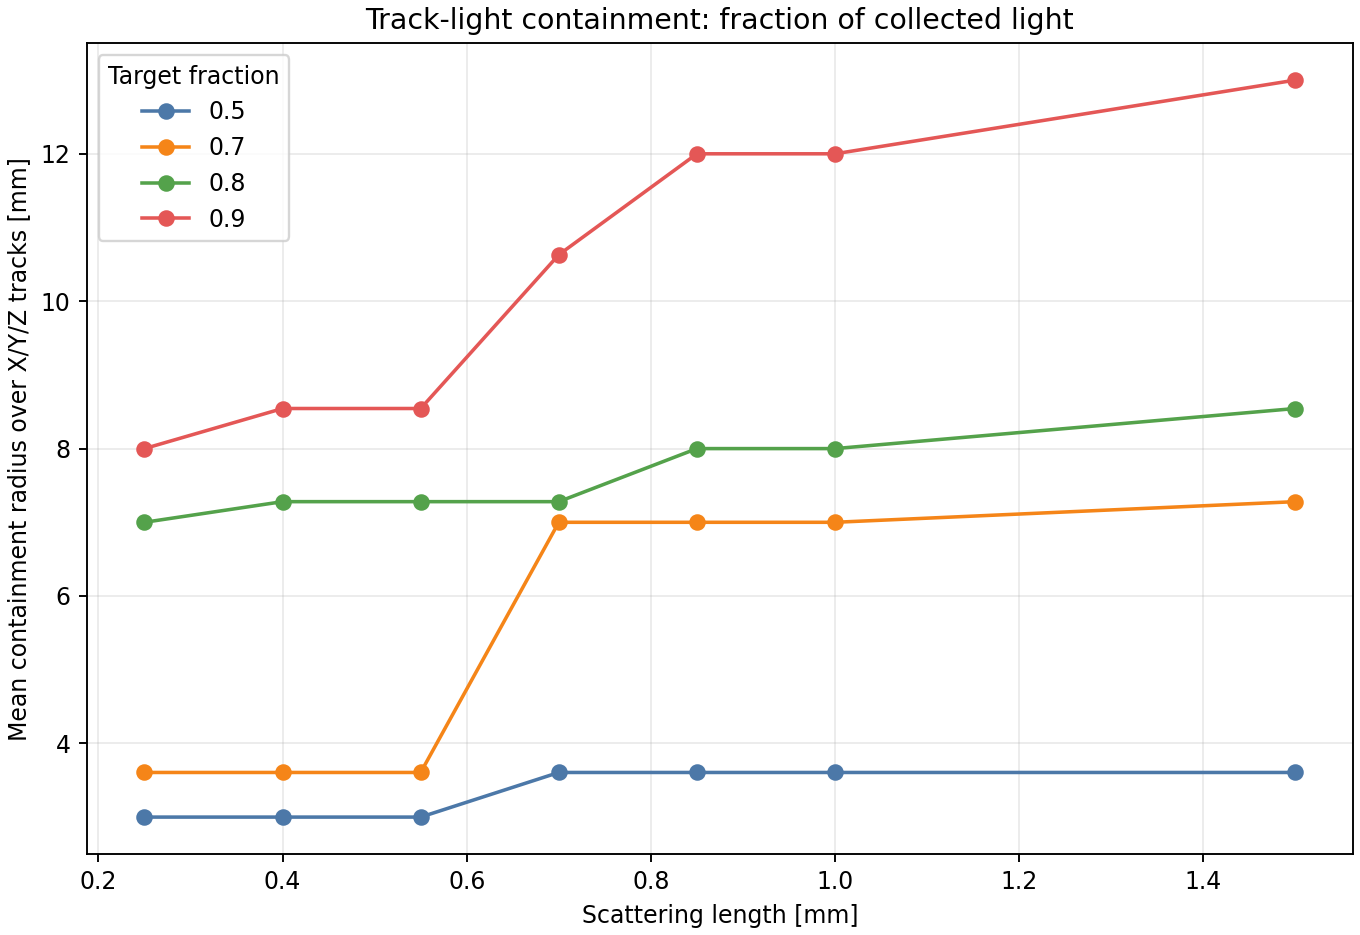

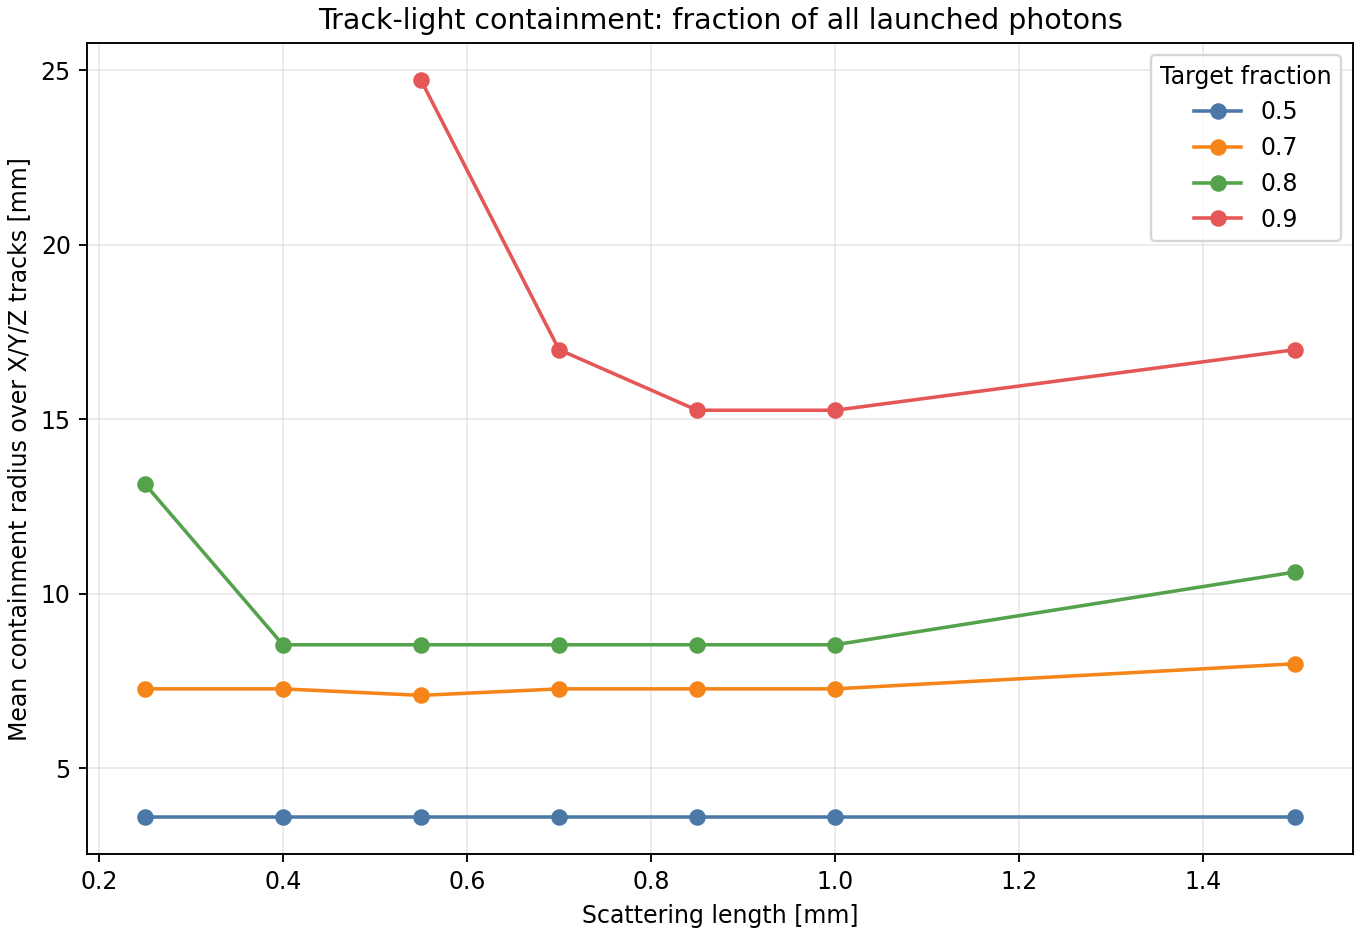

In [3]:
for name in ('total_efficiency_vs_scattering_length', 'view_efficiency_statistics_vs_scattering_length', 'nearest_fibre_statistics_vs_scattering_length', 'view_imbalance_vs_scattering_length', 'track_containment_relative_vs_scattering_length', 'track_containment_absolute_vs_scattering_length'):
    display(Image(filename=str(output_dir / f'{name}.png')))

`detailed[label]` contains one record per valid subvoxel for further interactive selections. The nearest fibre is selected independently in each view by the shortest perpendicular distance from the source point to that fibre axis.

## 2 mm fibres and matched-diameter comparison
The 2 mm maps are analysed separately. The final overlay cells use only scattering lengths present for both fibre diameters, so unmatched maps cannot silently enter the diameter comparison. Solid curves denote 1 mm fibres and dashed curves denote 2 mm fibres.

In [4]:
settings_2mm = [
    (0.40, '0.40 mm, 2 mm fibre', maps / 'homo_response_10bin_5m_0p4mm_fibre-2p0mm_100kPhotons.root'),
    (0.70, '0.70 mm, 2 mm fibre', maps / 'homo_response_10bin_5m_0p7mm_fibre-2p0mm_100kPhotons.root'),
    (1.00, '1.00 mm, 2 mm fibre', maps / 'homo_response_10bin_5m_1p0mm_fibre-2p0mm_100kPhotons.root'),
    (1.50, '1.50 mm, 2 mm fibre', maps / 'homo_response_10bin_5m_1p5mm_fibre-2p0mm_100kPhotons.root'),
]
output_dir_2mm = Path('lightmap_analysis/scattering_comparison_fibre_2p0mm')
summaries_2mm, detailed_2mm = compare_lightmaps(settings_2mm, output_dir_2mm)
summary_2mm = pd.DataFrame(summaries_2mm).sort_values('scatter_length_mm')
display(summary_2mm[['scatter_length_mm', 'positions', 'total_mean', 'total_min', 'total_max', 'total_rms']])

,scatter_length_mm,positions,total_mean,total_min,total_max,total_rms
0,0.4,970,0.720786,0.40128,0.79348,0.125469
1,0.7,970,0.788970,0.43115,0.86559,0.141904
2,1.0,970,0.820361,0.44686,0.90057,0.149351
3,1.5,970,0.846866,0.46156,0.93094,0.155741


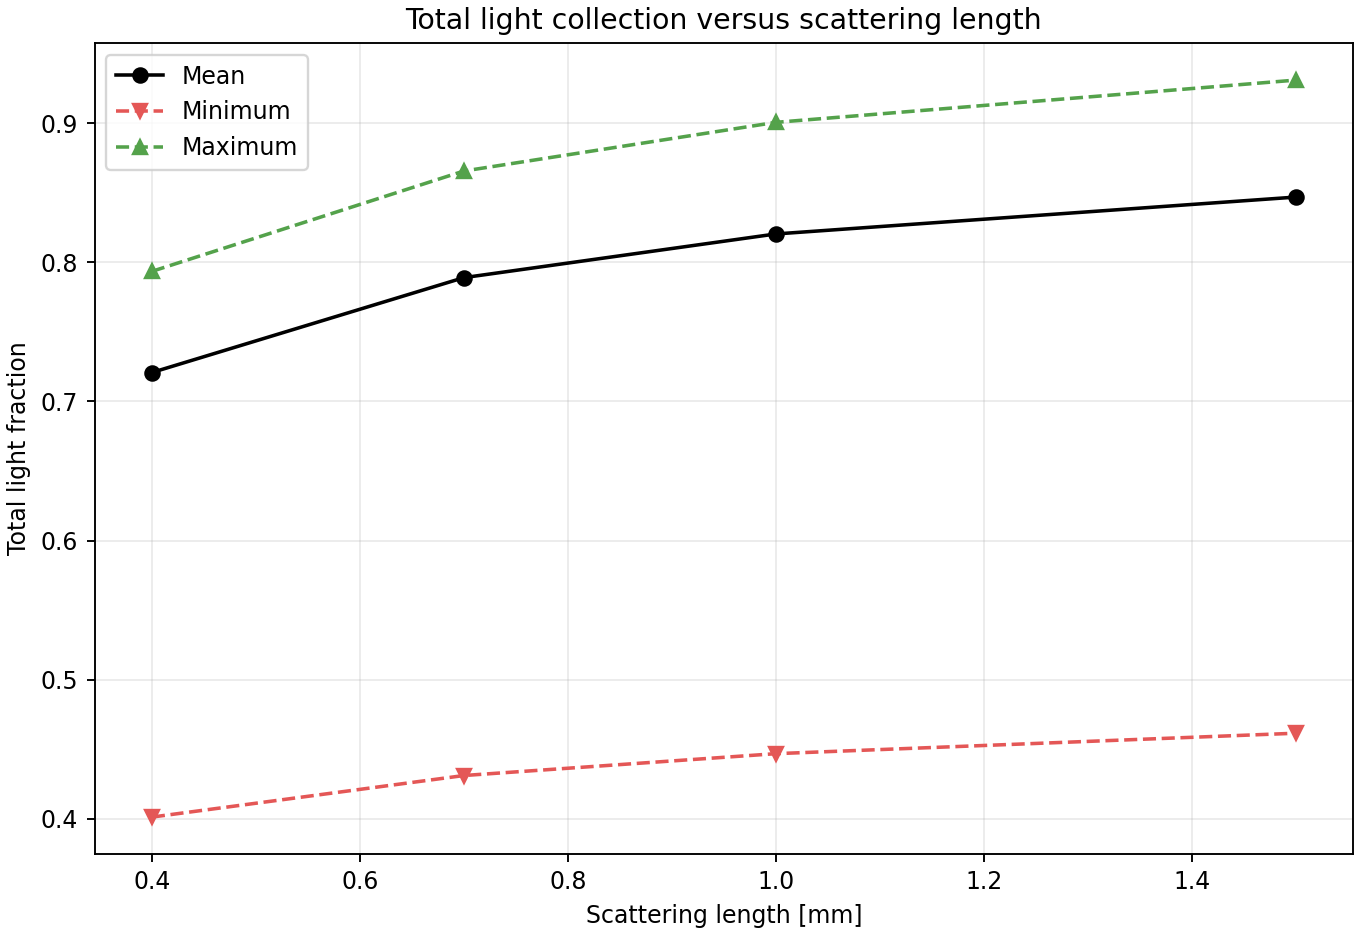

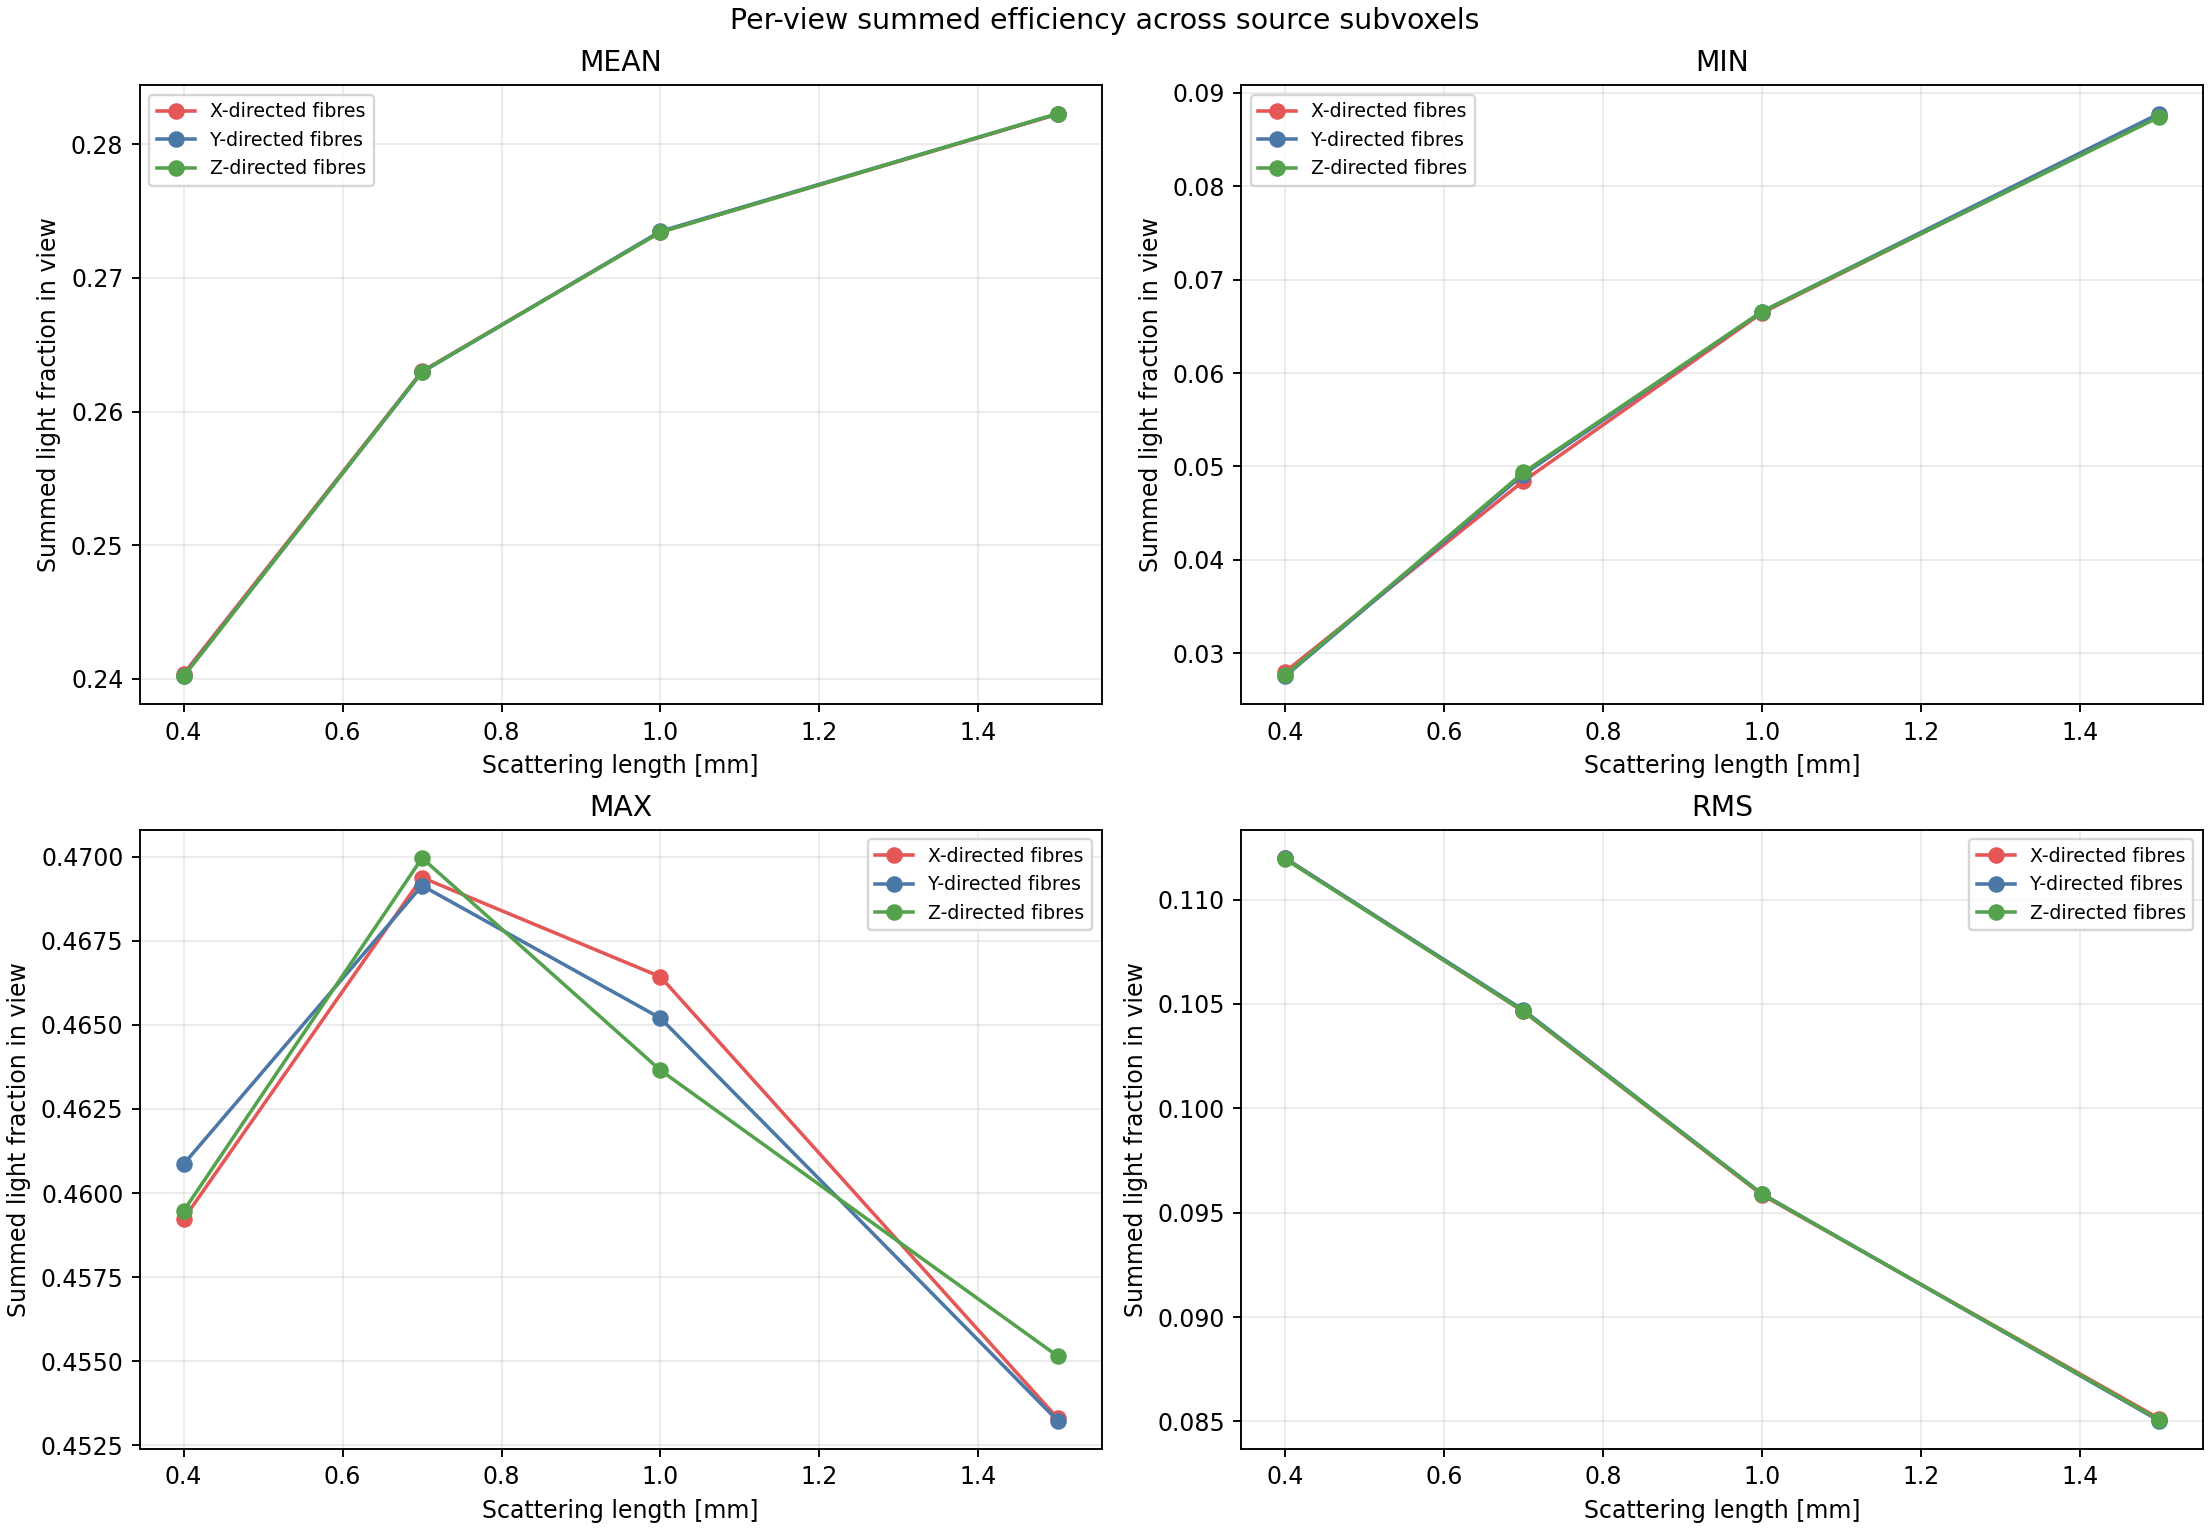

In [5]:
for name in ('total_efficiency_vs_scattering_length', 'view_efficiency_statistics_vs_scattering_length'):
    display(Image(filename=str(output_dir_2mm / f'{name}.png')))

### Provisional scintillator-volume correction for 2 mm fibres
The raw statistics weight every sampled source subvoxel equally. The coordinate mask below finds four adjacent subvoxels per fibre axis and longitudinal slice: 3 fibres × 4 neighbours × 10 slices = 120 partial subvoxels. They receive the requested provisional scintillator weight 0.5; the other 850 represented subvoxels receive weight 1. The 30 fibre-axis subvoxels are absent. This corrects population weighting, but not point sampling at a material boundary.

In [6]:
cube_centre_mm = (0.0, 30.0, 910.0)
fibre_axes = (
    (0, {1: -2.5, 2:  2.5}),  # X-directed fibre
    (1, {0:  2.5, 2: -2.5}),  # Y-directed fibre
    (2, {0: -2.5, 1:  2.5}),  # Z-directed fibre
)

def is_partial_2mm_subvoxel(record):
    relative = (record['x_mm'] - cube_centre_mm[0], record['y_mm'] - cube_centre_mm[1], record['z_mm'] - cube_centre_mm[2])
    return any(abs(sum((relative[coordinate] - value)**2 for coordinate, value in fixed.items()) - 1.0) < 1e-9 for _, fixed in fibre_axes)

def weighted_population_statistics(records, quantity):
    values = pd.Series([record[quantity] for record in records], dtype=float)
    weights = pd.Series([0.5 if is_partial_2mm_subvoxel(record) else 1.0 for record in records], dtype=float)
    mean = (weights * values).sum() / weights.sum()
    rms = ((weights * (values - mean)**2).sum() / weights.sum())**0.5
    return mean, rms, int((weights == 0.5).sum()), weights.sum()

weighted_rows = []
for scatter_length, label, _ in settings_2mm:
    records = detailed_2mm[label]
    row = {'scatter_length_mm': scatter_length}
    for quantity in ('total', 'view_x', 'view_y', 'view_z'):
        row[f'{quantity}_weighted_mean'], row[f'{quantity}_weighted_rms'], row['partial_subvoxels'], row['effective_subvoxels'] = weighted_population_statistics(records, quantity)
    weighted_rows.append(row)
summary_2mm_weighted = pd.DataFrame(weighted_rows).sort_values('scatter_length_mm')
display(summary_2mm_weighted)

,scatter_length_mm,total_weighted_mean,total_weighted_rms,partial_subvoxels,effective_subvoxels,view_x_weighted_mean,view_x_weighted_rms,view_y_weighted_mean,view_y_weighted_rms,view_z_weighted_mean,view_z_weighted_rms
0,0.4,0.741478,0.099288,120,910.0,0.247235,0.106927,0.247132,0.106945,0.247110,0.106909
1,0.7,0.812281,0.112601,120,910.0,0.270780,0.099483,0.270738,0.099546,0.270763,0.099513
2,1.0,0.844720,0.119096,120,910.0,0.281547,0.090494,0.281628,0.090530,0.281545,0.090524
3,1.5,0.872018,0.125007,120,910.0,0.290646,0.079319,0.290674,0.079188,0.290697,0.079222


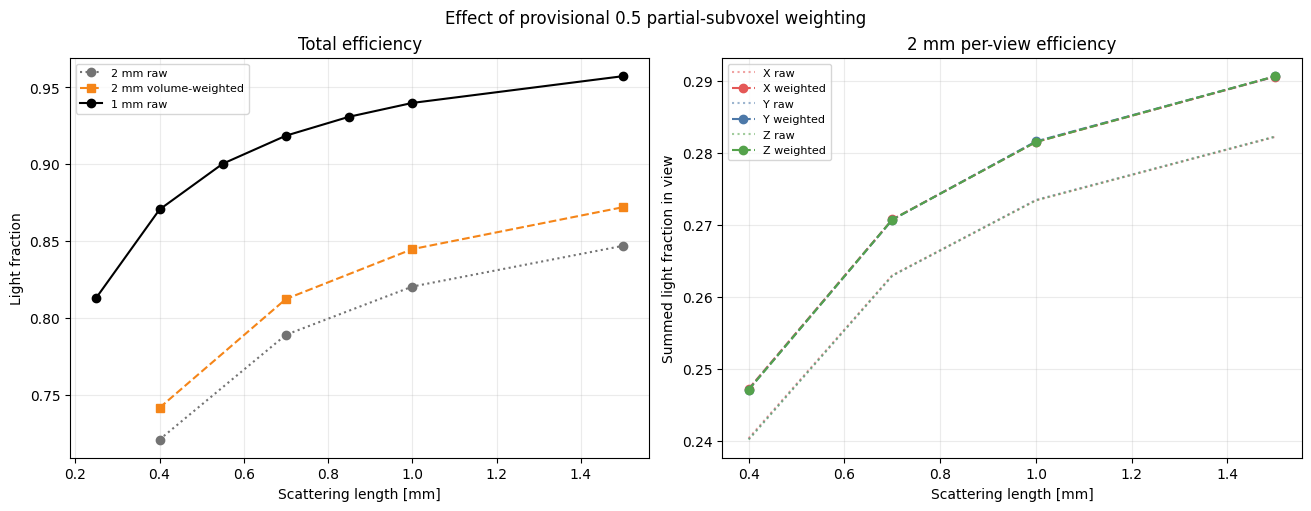

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
lengths_2mm = summary_2mm.scatter_length_mm.to_numpy()
axes[0].plot(lengths_2mm, summary_2mm.total_mean, 'o:', color='0.45', label='2 mm raw')
axes[0].plot(lengths_2mm, summary_2mm_weighted.total_weighted_mean, 's--', color='#f58518', label='2 mm volume-weighted')
axes[0].plot(summary.scatter_length_mm, summary.total_mean, 'o-', color='black', label='1 mm raw')
for view, colour in {'x': '#e45756', 'y': '#4c78a8', 'z': '#54a24b'}.items():
    axes[1].plot(lengths_2mm, summary_2mm[f'view_{view}_mean'], ':', color=colour, alpha=.55, label=f'{view.upper()} raw')
    axes[1].plot(lengths_2mm, summary_2mm_weighted[f'view_{view}_weighted_mean'], 'o--', color=colour, label=f'{view.upper()} weighted')
axes[0].set(title='Total efficiency', ylabel='Light fraction')
axes[1].set(title='2 mm per-view efficiency', ylabel='Summed light fraction in view')
for axis in axes:
    axis.set_xlabel('Scattering length [mm]'); axis.grid(alpha=.25); axis.legend(fontsize=8)
figure.suptitle('Effect of provisional 0.5 partial-subvoxel weighting')
figure.savefig(output_dir_2mm / 'volume_weighting_effect.png', dpi=170)
plt.show()

In [8]:
common_scattering_lengths = sorted(set(summary.scatter_length_mm) & set(summary_2mm.scatter_length_mm))
matched = {
    '1 mm fibre': summary[summary.scatter_length_mm.isin(common_scattering_lengths)].set_index('scatter_length_mm').loc[common_scattering_lengths],
    '2 mm fibre': summary_2mm[summary_2mm.scatter_length_mm.isin(common_scattering_lengths)].set_index('scatter_length_mm').loc[common_scattering_lengths],
}
output_dir_diameter = Path('lightmap_analysis/fibre_diameter_comparison')
output_dir_diameter.mkdir(parents=True, exist_ok=True)
print('Matched scattering lengths [mm]:', common_scattering_lengths)

Matched scattering lengths [mm]: [0.4, 0.7, 1.0, 1.5]


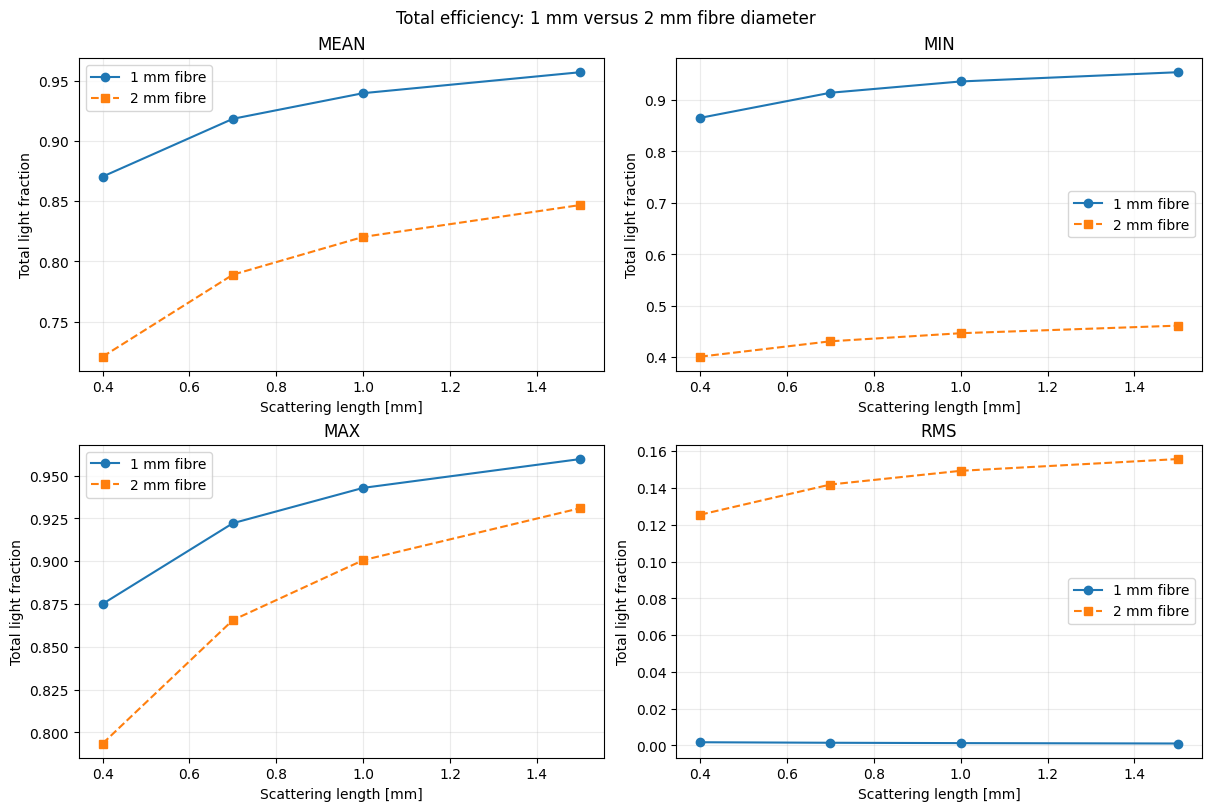

In [9]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
styles = {'1 mm fibre': ('-', 'o'), '2 mm fibre': ('--', 's')}
for axis, statistic in zip(axes.flat, ('mean', 'min', 'max', 'rms')):
    for diameter, frame in matched.items():
        linestyle, marker = styles[diameter]
        axis.plot(common_scattering_lengths, frame[f'total_{statistic}'], linestyle=linestyle, marker=marker, label=diameter)
    axis.set(title=statistic.upper(), xlabel='Scattering length [mm]', ylabel='Total light fraction')
    axis.grid(alpha=.25); axis.legend()
figure.suptitle('Total efficiency: 1 mm versus 2 mm fibre diameter')
figure.savefig(output_dir_diameter / 'matched_total_efficiency_1mm_vs_2mm.png', dpi=170)
plt.show()

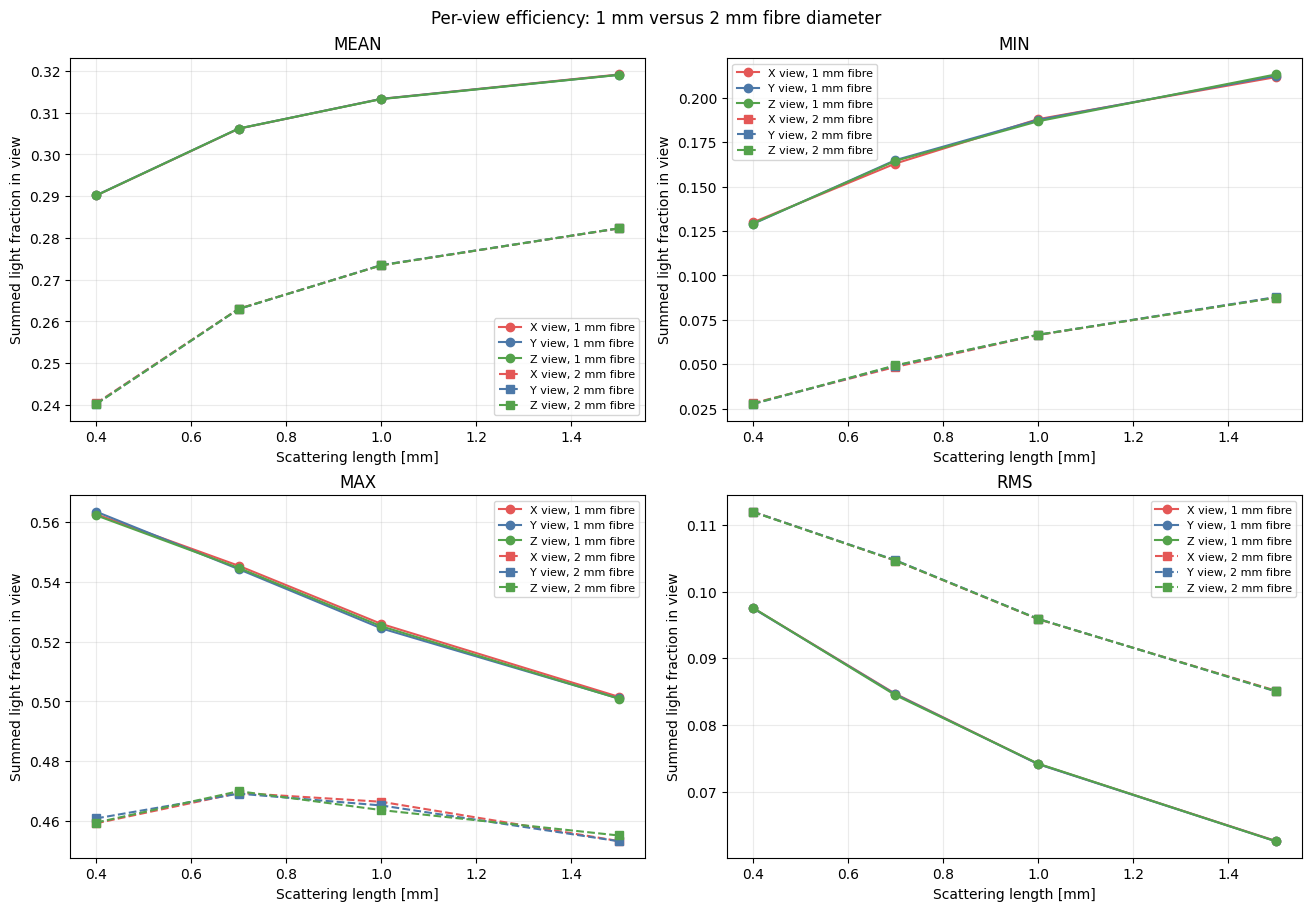

In [10]:
figure, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
view_colours = {'x': '#e45756', 'y': '#4c78a8', 'z': '#54a24b'}
for axis, statistic in zip(axes.flat, ('mean', 'min', 'max', 'rms')):
    for diameter, frame in matched.items():
        linestyle, marker = styles[diameter]
        for view in ('x', 'y', 'z'):
            axis.plot(common_scattering_lengths, frame[f'view_{view}_{statistic}'], linestyle=linestyle, marker=marker, color=view_colours[view], label=f'{view.upper()} view, {diameter}')
    axis.set(title=statistic.upper(), xlabel='Scattering length [mm]', ylabel='Summed light fraction in view')
    axis.grid(alpha=.25); axis.legend(fontsize=8)
figure.suptitle('Per-view efficiency: 1 mm versus 2 mm fibre diameter')
figure.savefig(output_dir_diameter / 'matched_view_efficiency_1mm_vs_2mm.png', dpi=170)
plt.show()